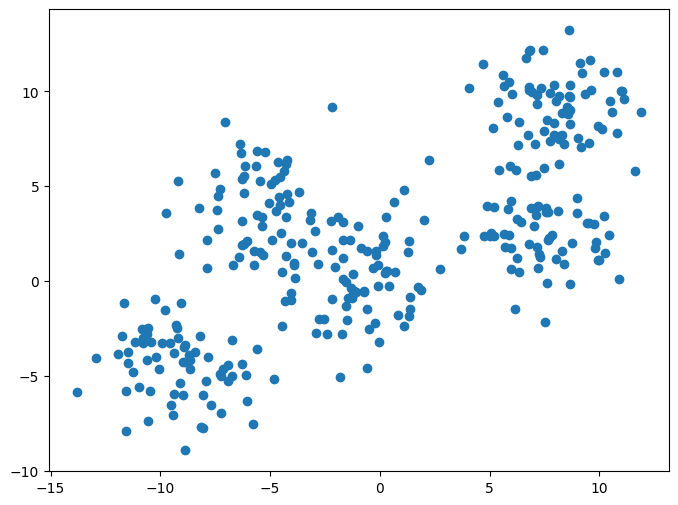

In [2]:
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from numpy import random
from pandas import DataFrame
from sklearn.cluster import KMeans

random.seed(234)
x, _ = make_blobs(n_samples=330, centers=5, cluster_std=1.84)
plt.figure(figsize=(8, 6))
plt.scatter(x[:, 0], x[:, 1])
plt.show()

In [4]:
gm = GaussianMixture(n_components=5).fit(x)
centers = gm.means_
print(centers)

[[ 7.28418475  2.56387124]
 [-9.18288987 -4.47852917]
 [-5.55836831  3.87299888]
 [ 8.11454324  9.24741885]
 [-0.90246061  0.16230294]]


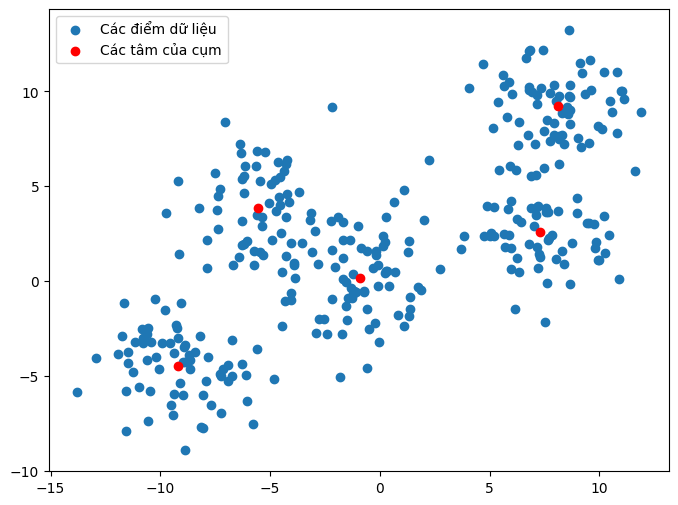

In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(x[:, 0], x[:, 1], label="Các điểm dữ liệu")
plt.scatter(centers[:, 0], centers[:, 1], c='r', label="Các tâm của cụm")
plt.legend()
plt.show()

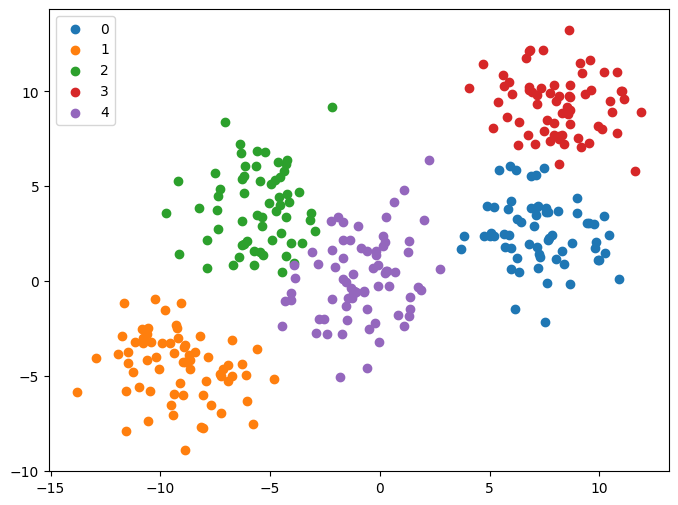

In [22]:
pred = gm.predict(x)

df = DataFrame({'x':x[:,0], 'y':x[:, 1], 'label':pred})
groups = df.groupby('label')

plt.figure(figsize=(8, 6))
for name, group in groups:
    plt.scatter(group.x, group.y, label=name)

plt.legend()
plt.show()

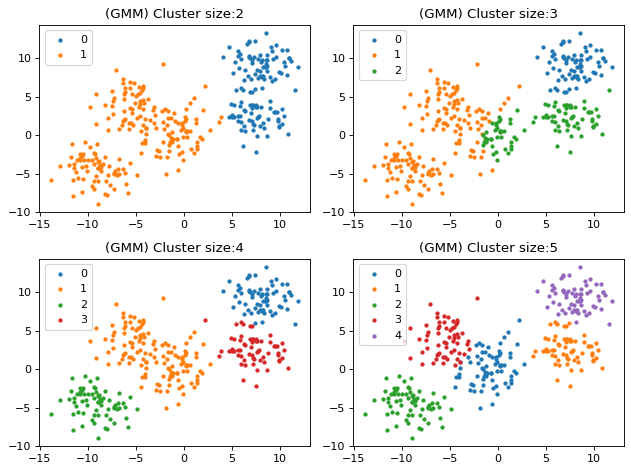

In [ ]:
f = plt.figure(figsize=(8, 6), dpi=80)

for i in range(2, 6):
    gm = GaussianMixture(n_components=i).fit(x)
    pred = gm.predict(x)
    df = DataFrame({'x':x[:,0], 'y':x[:, 1], 'label':pred})
    groups = df.groupby('label')
    f.add_subplot(2, 2, i - 1)
    for name, group in groups:
        plt.scatter(group.x, group.y, label=name, s=8)
        plt.title("(GMM) Cluster size:" + str(i))
        plt.legend()

plt.tight_layout()
plt.show()

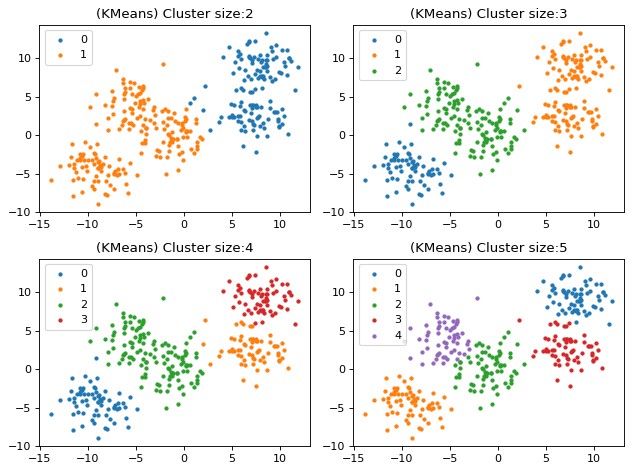

In [27]:
f = plt.figure(figsize=(8, 6), dpi=80)

for i in range(2, 6):
    km = KMeans(n_clusters=i).fit(x)
    pred = km.predict(x)
    df = DataFrame({'x':x[:,0], 'y':x[:, 1], 'label':pred})
    groups = df.groupby('label')
    f.add_subplot(2, 2, i - 1)
    for name, group in groups:
        plt.scatter(group.x, group.y, label=name, s=8)
        plt.title("(KMeans) Cluster size:" + str(i))
        plt.legend()

plt.tight_layout()
plt.show()